<a href="https://colab.research.google.com/github/gauravpatra03-sketch/Deep-Learning/blob/main/GenAI_Week4_Ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:
import tensorflow as tf
from keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

Load Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Sampling Layer

In [3]:
latent_dim = 16
num_classes = 10

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

Encoder

In [4]:
image_input = layers.Input(shape=(784,))
label_input = layers.Input(shape=(num_classes,))

encoder_input = layers.Concatenate()(
    [image_input, label_input]
)

x = layers.Dense(256, activation='relu')(encoder_input)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(
    [image_input, label_input],
    [z_mean, z_log_var, z],
    name='Encoder'
)

Decoder

In [5]:
latent_input = layers.Input(shape=(latent_dim,))
label_decoder = layers.Input(shape=(num_classes,))

decoder_input = layers.Concatenate()(
    [latent_input, label_decoder]
)

x = layers.Dense(256, activation='relu')(decoder_input)

decoder_output = layers.Dense(
    784,
    activation='sigmoid'
)(x)

decoder = Model(
    [latent_input, label_decoder],
    decoder_output,
    name='Decoder'
)

CVAE Model

In [12]:
from functools import total_ordering
class CVAE(Model):

  def __init__(self, encoder, decoder, **kwargs):
    super(CVAE, self).__init__(**kwargs)
    self.encoder = encoder
    self.decoder = decoder

  def call(self, inputs):

    image, label=inputs

    z_mean, z_log_var, z=self.encoder(
        [image, label]
    )

    return self.decoder(
        [z, label]
    )

  def train_step(self, data):

    (image, label) = data[0]

    with tf.GradientTape() as tape:

      z_mean, z_log_var, z = self.encoder(
          [image, label]
      )

      reconstruction = self.decoder(
          [z, label]
      )

      reconstruction_loss = tf.reduce_mean(
          tf.keras.losses.binary_crossentropy(
              image,
              reconstruction
          )
      )

      kl_loss = -0.5 * tf.reduce_mean(
          1+z_log_var-tf.square(z_mean)
          -tf.square(z_mean)
          -tf.exp(z_log_var)
      )

      total_loss = (
          reconstruction_loss + kl_loss
      )

    grads = tape.gradient(
        total_loss,
        self.trainable_weights
    )

    self.optimizer.apply_gradients(
        zip(grads, self.trainable_weights)
    )

    return {
        "loss": total_loss,
        "reconstruction_loss": reconstruction_loss,
        "kl_loss": kl_loss
    }

Create CVAE

In [13]:
cvae=CVAE(
    encoder,
    decoder
)

cvae.compile(
    optimizer="adam"
)

Train CVAE

In [14]:
history = cvae.fit(
    [x_train, y_train],
    epochs=10,
    batch_size=128
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - kl_loss: 1.8615e-05 - loss: 0.2268 - reconstruction_loss: 0.2268
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - kl_loss: 1.8810e-05 - loss: 0.2238 - reconstruction_loss: 0.2238
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss: 3.9077e-06 - loss: 0.2160 - reconstruction_loss: 0.2160
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - kl_loss: 1.2806e-06 - loss: 0.2181 - reconstruction_loss: 0.2181
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss: 4.0243e-07 - loss: 0.2176 - reconstruction_loss: 0.2176
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - kl_loss: 4.6752e-07 - loss: 0.2209 - reconstruction_loss: 0.2209
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss: 1.0414e-06 - loss: 0.2298 - reconstruction_loss: 0.2298
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - kl_loss: 1.0956e-06 - loss: 0.2159 - reconstruction_loss: 0.2159
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 

Reconstruct Test Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


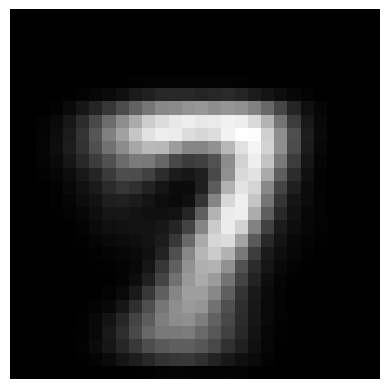

In [17]:
# Random latent vector
z = np.random.normal(
    size=(1, latent_dim)
)

# Label 7
label= tf.keras.utils.to_categorical(
    [7],
    num_classes=10
)

generated = decoder.predict(
    [z, label]
)

plt.imshow(
    generated.reshape(28,28),
    cmap='gray'
)

plt.axis("off")
plt.show()